In [1]:
! pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.3/949.3 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9

In [2]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import display, Image
import glob


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:

from roboflow import Roboflow
rf = Roboflow(api_key="TafTnLjXkvLUpxGZP8JU")
project = rf.workspace("id-card-vf1zl").project("idea1")
version = project.version(5)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to idea1-5 in yolov12:: 100%|██████████| 862/862 [00:00<00:00, 5019.18it/s]


In [5]:
!yolo task=detect mode=train model=yolov12n.pt data={dataset.location}/data.yaml epochs=30 imgsz=640

Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.pt, data=/content/idea1-5/data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxe

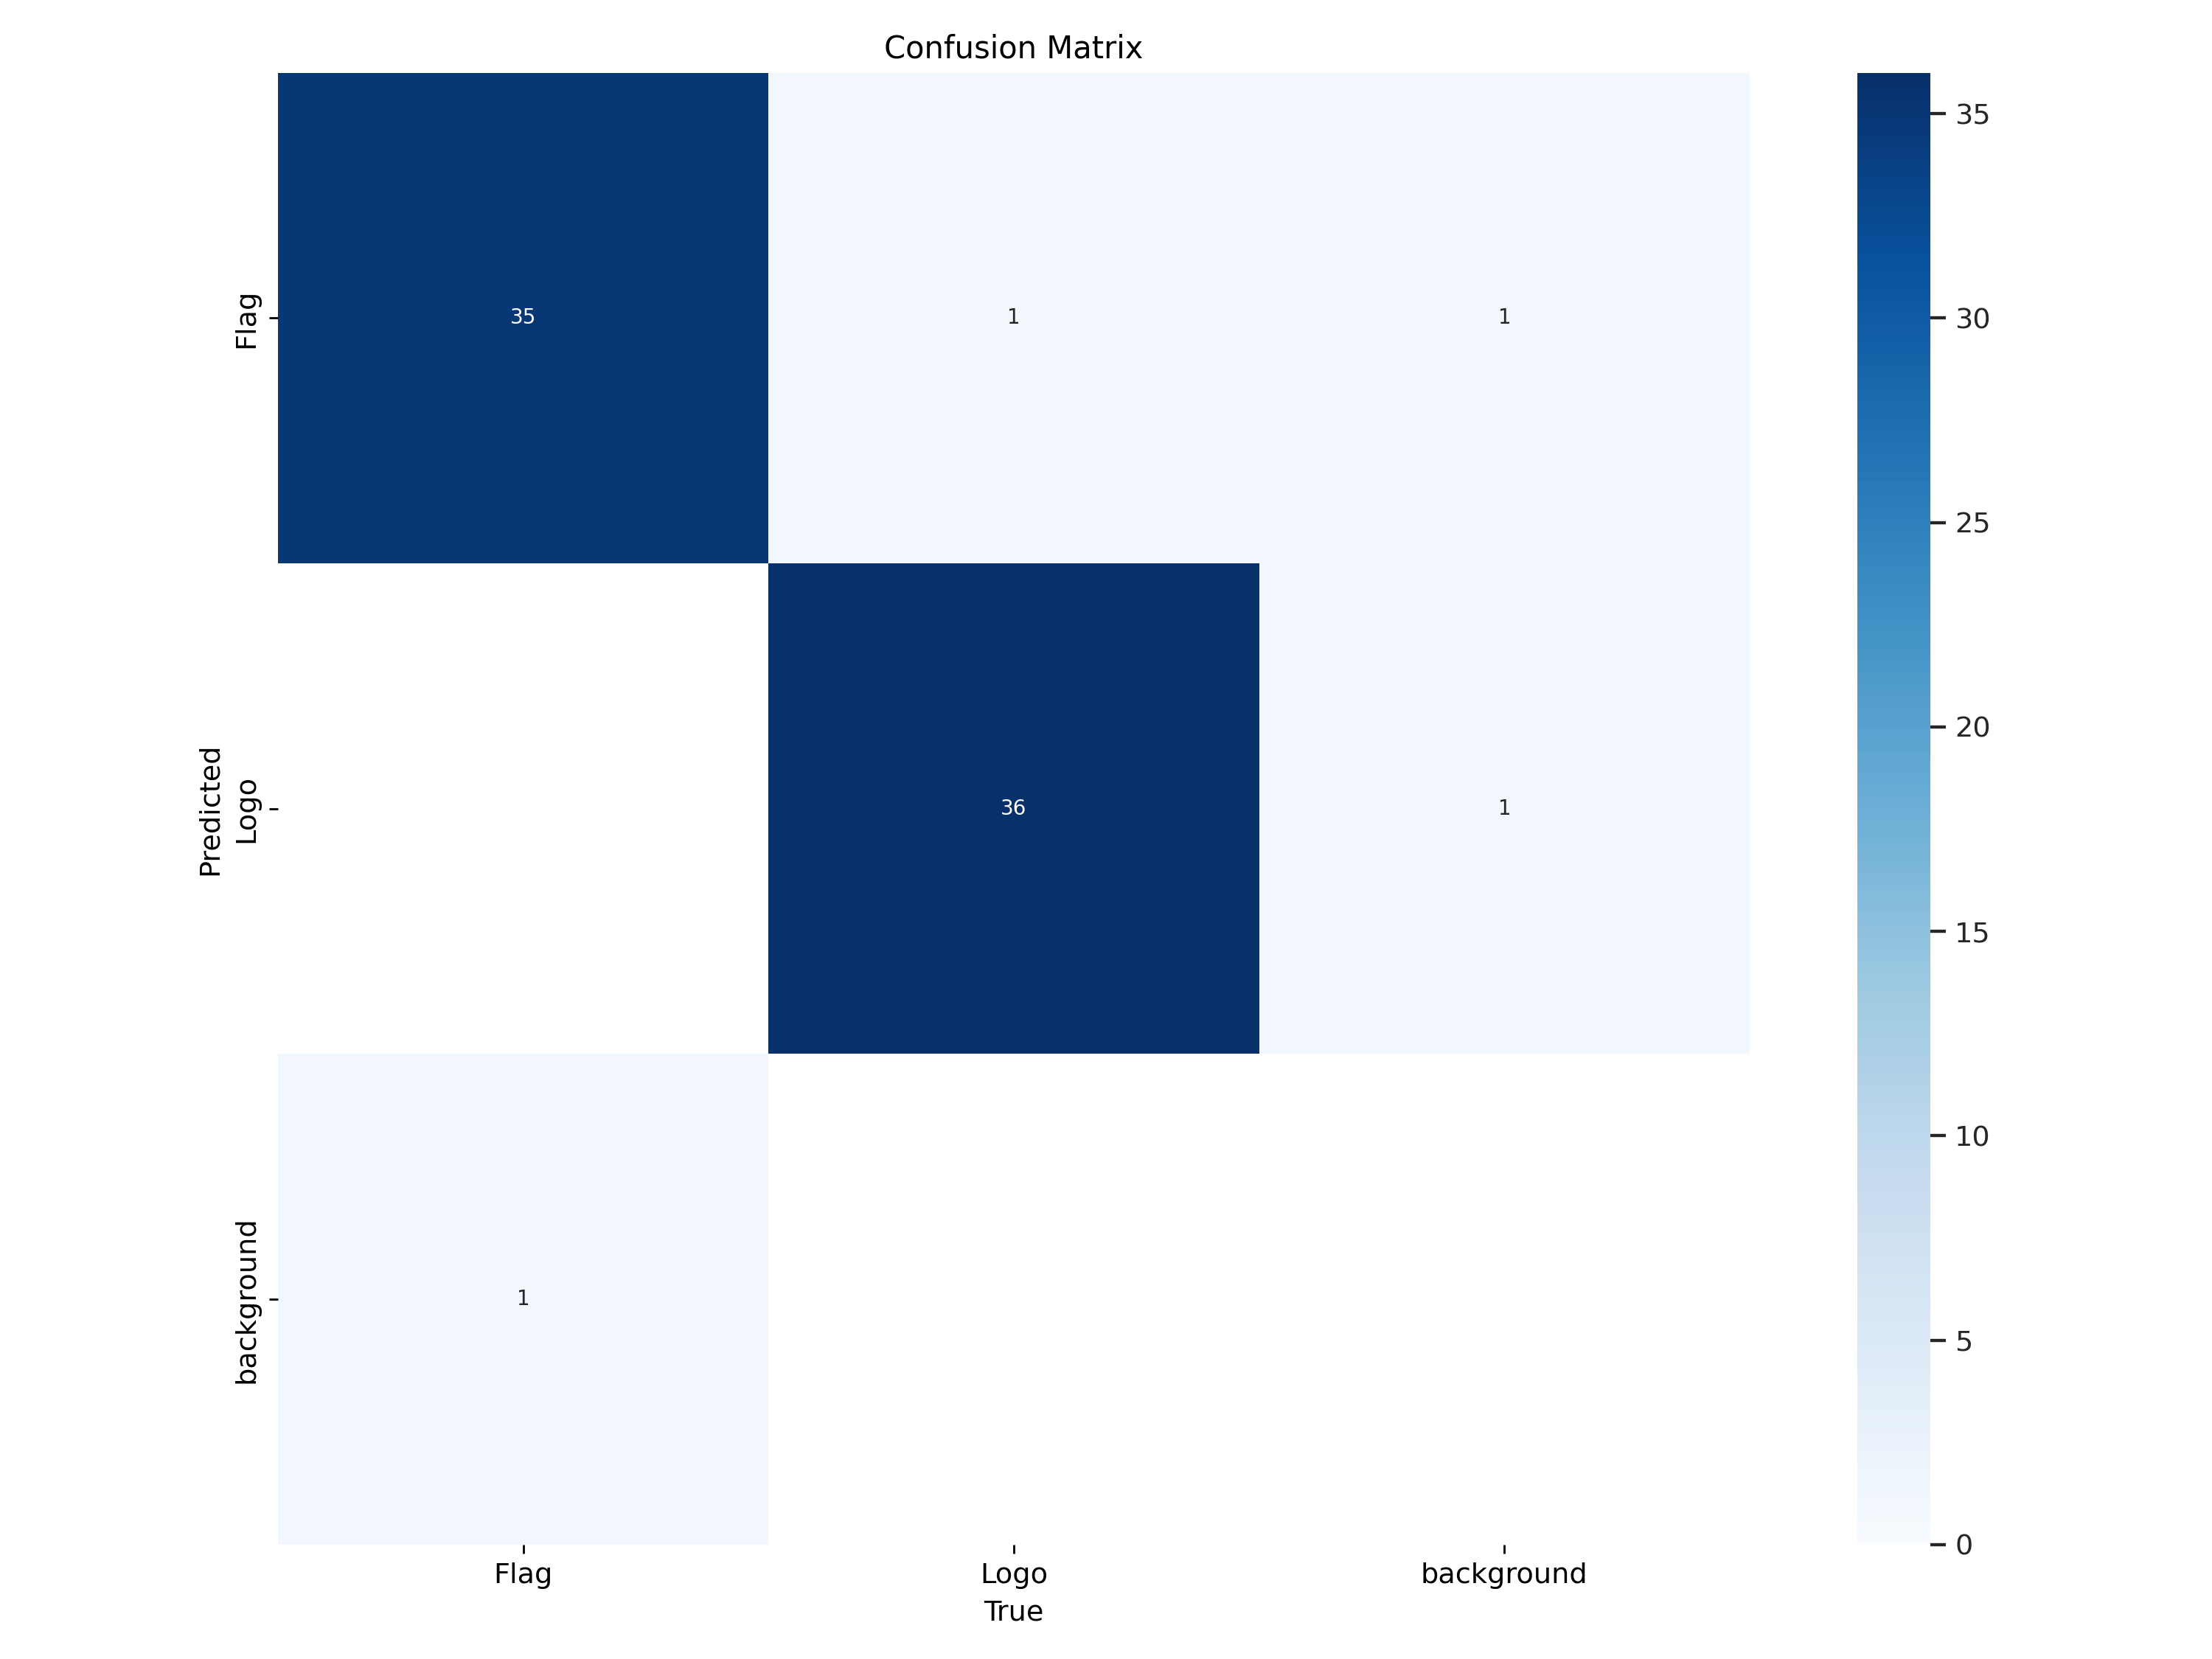

In [7]:
Image(filename=f'runs/detect/train/confusion_matrix.png', width=600)

In [9]:
model = YOLO('runs/detect/train/weights/best.pt')

In [35]:
def rotate_idcard(image_path):
  import cv2
  import math
  import numpy as np
  from google.colab.patches import cv2_imshow
  r = model.predict(source=image_path, show=False, conf=0.5)

  result = r[0]
  boxes = result.boxes.xyxy.cpu().numpy().astype(int)
  confidences = result.boxes.conf.cpu().numpy()
  class_ids = result.boxes.cls.cpu().numpy().astype(int)
  class_names = result.names

  image = result.orig_img.copy()


  flag_x1, flag_y1, flag_x2, flag_y2 = boxes[0]
  flag_center_x = (flag_x1 + flag_x2) // 2
  flag_center_y = (flag_y1 + flag_y2) // 2


  flag_class_id = class_ids[0]
  flag_class_name = class_names[flag_class_id]


  logo_x1, logo_y1, logo_x2, logo_y2 = boxes[1]
  logo_center_x = (logo_x1 + logo_x2) // 2
  logo_center_y = (logo_y1 + logo_y2) // 2

  logo_class_id = class_ids[1]
  logo_class_name = class_names[logo_class_id]

  cv2.rectangle(image, (flag_x1, flag_y1), (flag_x2, flag_y2), (0, 255, 0), 2)
  cv2.putText(image, flag_class_name, (flag_x1, flag_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
  cv2.circle(image, (flag_center_x, flag_center_y), 5, (0, 255, 0), -1)

  cv2.rectangle(image, (logo_x1, logo_y1), (logo_x2, logo_y2), (255, 0, 0), 2)
  cv2.putText(image, logo_class_name, (logo_x1, logo_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
  cv2.circle(image, (logo_center_x, logo_center_y), 5, (255, 0, 0), -1)
  cv2_imshow(image)


  slope = (logo_center_y - flag_center_y) / (logo_center_x - flag_center_x)
  angle = np.arctan(slope)
  rotation_angle = np.degrees(angle)

  center = (image.shape[1] // 2, image.shape[0] // 2)


  rotation_matrix = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
  rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))



  return(rotated_image)